# Parcellation

This notebook extracts Schaefer-100 cortical and Melbourne/Tian Scale 1 subcortical time series for the LEiDA/EiDA and synchrony/metastability analyses. The output order is 100 cortical parcels followed by 16 subcortical parcels.

In [1]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import nibabel as nib
import numpy as np
import pandas as pd
import requests
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch
from nilearn import plotting
from nilearn.datasets import fetch_atlas_schaefer_2018, load_mni152_template
from nilearn.image import resample_to_img
from nilearn.maskers import NiftiLabelsMasker

## Paths and participants

In [2]:
project_root = Path("/Users/markfahy/Imperial/Thesis")
data_root = project_root / "MarkDynamics 2"
atlas_dir = project_root / "atlases"
output_dir = data_root / "parcellation_outputs"

excluded_subjects = {15, 17, 19, 27, 36, 42, 46}
subjects = [subject for subject in range(1, 51) if subject not in excluded_subjects]

print("Participants:", len(subjects))
print("Scans:", 2 * len(subjects))

Participants: 43
Scans: 86


## Clinical data
Insert patient outcome data as described in the commented section when acquired by the Imperial Centre for Psychedelic Research 

In [ ]:
clinical_data = #Dataframe with rows of (Treatment group, Patient Number, Pre-treatment QIDS score, Post-treatment QIDS score) for each patient

clinical_data["treatment"] = clinical_data["treatment"].map({
    "E": "escitalopram",
    "P": "psilocybin",
})
clinical_data["qids_reduction"] = clinical_data["qids_pre"] - clinical_data["qids_post"]
clinical_data["qids_percent_reduction"] = (
    100 * clinical_data["qids_reduction"] / clinical_data["qids_pre"]
)
clinical_data["responder_50pct"] = clinical_data["qids_percent_reduction"] >= 50
clinical_data["achieved_remission"] = clinical_data["qids_post"] <= 5
clinical_data["response_status"] = np.where(
    clinical_data["responder_50pct"],
    "responder",
    "non_responder",
)
clinical_data["remission_status"] = np.where(
    clinical_data["achieved_remission"],
    "remission",
    "non_remission",
)

## Parcellation atlas
Downloading the combined atlases

In [4]:
atlas_name = (
    "Schaefer2018_100Parcels_7Networks_order_"
    "Tian_Subcortex_S1_3T_MNI152NLin2009cAsym_2mm.nii.gz"
)
atlas_url = (
    "https://raw.githubusercontent.com/yetianmed/subcortex/master/"
    "Group-Parcellation/3T/Cortex-Subcortex/MNIvolumetric/"
    + atlas_name
)
atlas_path = atlas_dir / atlas_name

atlas_dir.mkdir(exist_ok=True)
if not atlas_path.exists():
    atlas_path.write_bytes(requests.get(atlas_url).content)

atlas_img = nib.load(atlas_path)
print("Atlas shape:", atlas_img.shape)
print("Parcels: 116")

Atlas shape: (97, 115, 97)
Parcels: 116


## Cortical networks and subcortical regions

The cortical parcels are coloured by Yeo-7 network. The lower row shows the 16 Melbourne/Tian Scale 1 subcortical regions. For the proceeding plot to run the melborune subcortical atlas in its 16-parcel resolution must be downloaded directly from https://www.nitrc.org/projects/msa/

In [ ]:
schaefer = fetch_atlas_schaefer_2018(
    n_rois=100,
    yeo_networks=7,
    resolution_mm=1,
)
schaefer_img = nib.load(str(schaefer.maps))
schaefer_data = np.asarray(schaefer_img.dataobj, dtype=np.int16)
parcel_labels = [
    label.decode("utf-8") if isinstance(label, bytes) else str(label)
    for label in schaefer.labels
]
if len(parcel_labels) == 101:
    parcel_labels = parcel_labels[1:]

networks = [
    ("Vis", "Visual", "#1F77B4"),
    ("SomMot", "Somatomotor", "#FF7F0E"),
    ("DorsAttn", "Dorsal Attention", "#2CA02C"),
    ("SalVentAttn", "Salience / Ventral Attention", "#D62728"),
    ("Limbic", "Limbic", "#9467BD"),
    ("Cont", "Control / Frontoparietal", "#8C564B"),
    ("Default", "Default Mode", "#E377C2"),
]

network_data = np.zeros_like(schaefer_data)
for parcel_value, parcel_label in enumerate(parcel_labels, start=1):
    for network_value, (network_code, _, _) in enumerate(networks, start=1):
        if f"_{network_code}_" in f"_{parcel_label}_":
            network_data[schaefer_data == parcel_value] = network_value

network_img = nib.Nifti1Image(
    network_data,
    affine=schaefer_img.affine,
    header=schaefer_img.header,
)

melbourne_dir = Path.home() / "brain_atlas_figures"
##requires download of melbourne subcortex from website (linked above)
melbourne_img = nib.load(melbourne_dir / "melbourne_subcortex_scale1.nii")
with (melbourne_dir / "melbourne_subcortex_scale1.json").open(encoding="utf-8") as file:
    melbourne_legend = sorted(json.load(file), key=lambda item: int(item["value"]))

mni_template = load_mni152_template()
schaefer_background = resample_to_img(
    source_img=mni_template,
    target_img=schaefer_img,
    interpolation="continuous",
)
melbourne_background = resample_to_img(
    source_img=mni_template,
    target_img=melbourne_img,
    interpolation="continuous",
)

[fetch_atlas_schaefer_2018] Dataset found in /Users/markfahy/nilearn_data/schaefer_2018


/var/folders/z_/gk1bw4ks53xbl9cm5s1_0r_00000gn/T/ipykernel_3797/3416349556.py:111: UserWarning: kwargs['alpha']=0.45 detected in parameters.
Overriding with transparency=None.
To suppress this warning pass your 'alpha' value via the 'transparency' parameter.
  subcortical_display.add_contours(


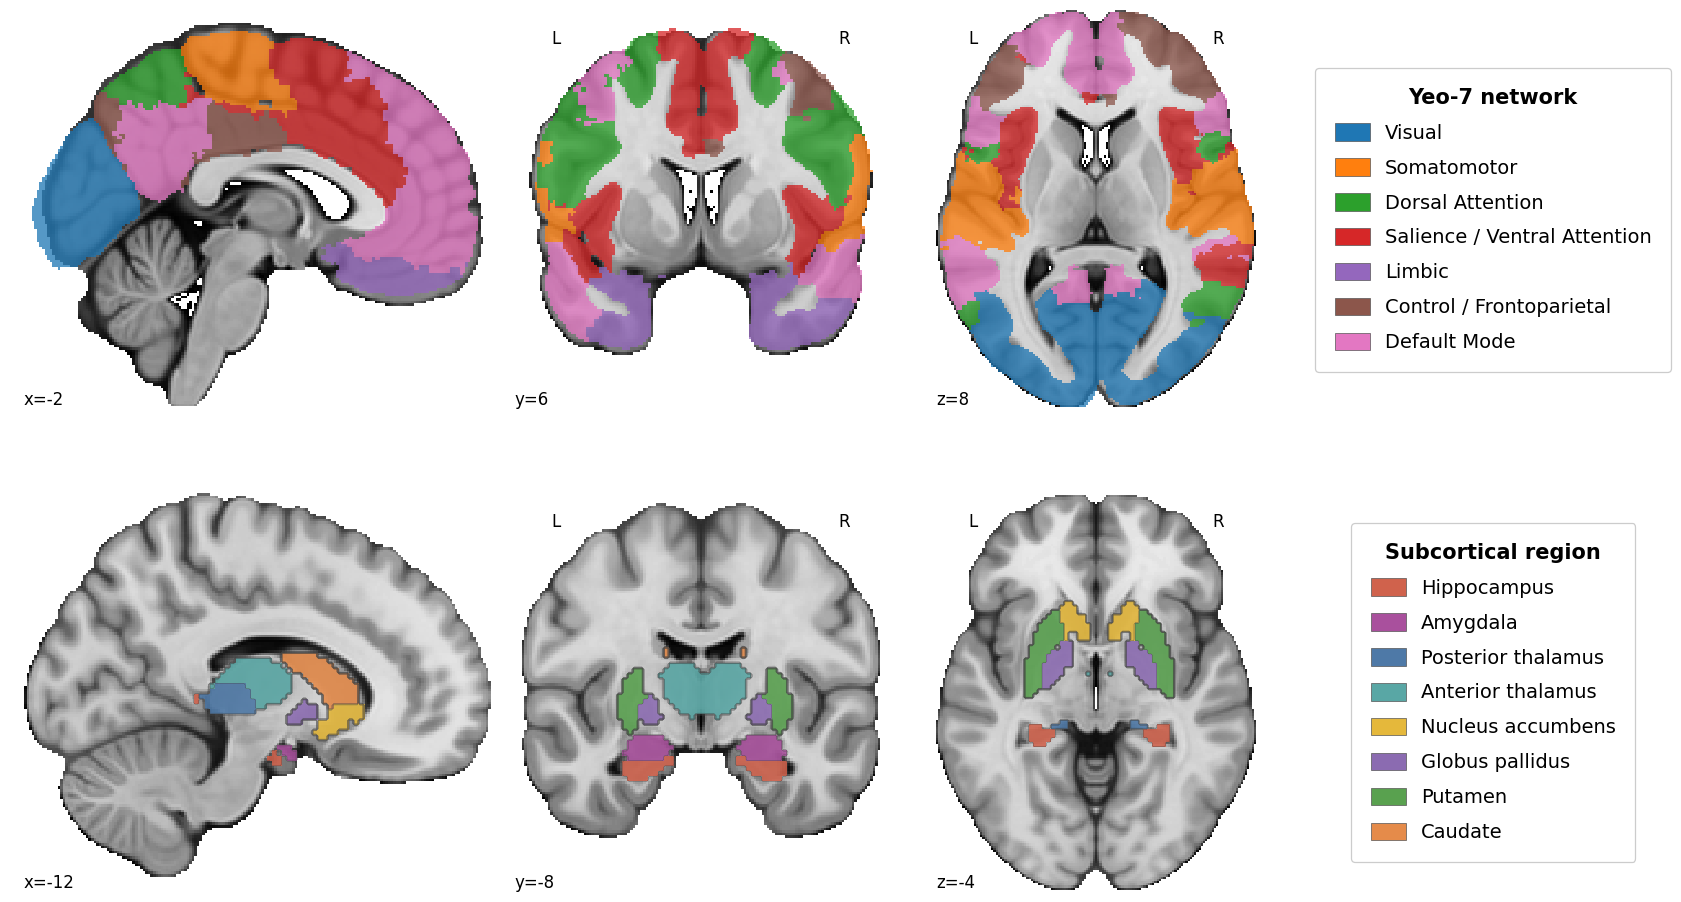

In [ ]:
fig = plt.figure(
    figsize=(17, 10.5),
    facecolor="white",
)


# Cortical Yeo-7 networks
cortical_axes = fig.add_axes([
    0.015,
    0.53,
    0.755,
    0.38,
])

cortical_legend_axes = fig.add_axes([
    0.785,
    0.56,
    0.205,
    0.30,
])
cortical_legend_axes.axis("off")

plotting.plot_roi(
    roi_img=network_img,
    bg_img=schaefer_background,
    display_mode="ortho",
    cut_coords=(-2, 6, 8),
    draw_cross=False,
    annotate=True,
    cmap=ListedColormap([
        colour
        for _, _, colour in networks
    ]),
    colorbar=False,
    black_bg=False,
    alpha=0.76,
    threshold=0.5,
    dim=-0.35,
    figure=fig,
    axes=cortical_axes,
)

cortical_legend = cortical_legend_axes.legend(
    handles=[
        Patch(
            facecolor=colour,
            edgecolor="#555555",
            linewidth=0.5,
            label=name,
        )
        for _, name, colour in networks
    ],
    loc="center",
    title="Yeo-7 network",
    title_fontsize=15,
    fontsize=14,
    frameon=True,
    fancybox=True,
    framealpha=1,
    facecolor="white",
    edgecolor="#CCCCCC",
    borderpad=1,
    labelspacing=0.8,
    handlelength=1.8,
    handleheight=1,
    handletextpad=0.8,
)

cortical_legend.get_title().set_fontweight(
    "semibold"
)
cortical_legend.get_frame().set_linewidth(0.9)
subcortical_axes = fig.add_axes([
    0.015,
    0.07,
    0.755,
    0.38,
])
subcortical_legend_axes = fig.add_axes([
    0.785,
    0.09,
    0.205,
    0.34,
])
subcortical_legend_axes.axis("off")

subcortical_display = plotting.plot_roi(
    roi_img=melbourne_img,
    bg_img=melbourne_background,
    display_mode="ortho",
    cut_coords=(-12, -8, -4),
    draw_cross=False,
    annotate=True,
    cmap=ListedColormap([
        item["hex"]
        for item in melbourne_legend
    ]),
    colorbar=False,
    black_bg=False,
    alpha=0.88,
    threshold=0.5,
    dim=-0.30,
    figure=fig,
    axes=subcortical_axes,
)

subcortical_display.add_contours(
    melbourne_img,
    levels=np.arange(
        0.5,
        max(
            int(item["value"])
            for item in melbourne_legend
        ) + 0.5,
        1,
    ),
    colors="#444444",
    linewidths=0.25,
    alpha=0.45,
)

subcortical_legend = subcortical_legend_axes.legend(
    handles=[
        Patch(
            facecolor=item["hex"],
            edgecolor="#555555",
            linewidth=0.5,
            label=item["label"],
        )
        for item in melbourne_legend
    ],
    loc="center",
    title="Subcortical region",
    title_fontsize=15,
    fontsize=14,
    frameon=True,
    fancybox=True,
    framealpha=1,
    facecolor="white",
    edgecolor="#CCCCCC",
    borderpad=1,
    labelspacing=0.8,
    handlelength=1.8,
    handleheight=1,
    handletextpad=0.8,
)

subcortical_legend.get_title().set_fontweight(
    "semibold"
)
subcortical_legend.get_frame().set_linewidth(0.9)

plt.show()

## Scan manifest

In [7]:
scans = []

for subject in subjects:
    for session, timepoint in [(1, "pre"), (2, "post")]:
        scan_id = f"sub-{subject}_ses-{session}"
        scans.append({
            "scan_id": scan_id,
            "subject": subject,
            "session": session,
            "timepoint": timepoint,
            "path": (
                data_root
                / f"sub-{subject}"
                / f"ses-{session}"
                / "func"
                / (
                    f"cleaned_{scan_id}_task-rest_"
                    "space-MNI152NLin2009cAsym.nii.gz"
                )
            ),
        })

scan_manifest = pd.DataFrame(scans).merge(clinical_data, on="subject", how="left")
print("Scans in manifest:", len(scan_manifest))

Scans in manifest: 86


## Extract parcel time series

In [ ]:
masker = NiftiLabelsMasker(
    labels_img=atlas_path,
    strategy="mean",
    resampling_target="data",
)

all_timeseries = []

for scan in scan_manifest.itertuples(index=False):
    print("Parcellating:", scan.scan_id)
    scan_timeseries = masker.fit_transform(scan.path)

    #The combined atlas is stored as 16 subcortical then 100 cortical parcels.
    #This just reorders it to 100 cortical then 16 subcortical parcels.
    scan_timeseries = np.column_stack([
        scan_timeseries[:, 16:],
        scan_timeseries[:, :16],
    ])
    all_timeseries.append(scan_timeseries)

all_timeseries = np.stack(all_timeseries).astype(np.float32)
print("Time-series shape:", all_timeseries.shape)

Parcellating: sub-1_ses-1
Parcellating: sub-1_ses-2
Parcellating: sub-2_ses-1
Parcellating: sub-2_ses-2
Parcellating: sub-3_ses-1
Parcellating: sub-3_ses-2
Parcellating: sub-4_ses-1
Parcellating: sub-4_ses-2
Parcellating: sub-5_ses-1
Parcellating: sub-5_ses-2
Parcellating: sub-6_ses-1
Parcellating: sub-6_ses-2
Parcellating: sub-7_ses-1
Parcellating: sub-7_ses-2
Parcellating: sub-8_ses-1
Parcellating: sub-8_ses-2
Parcellating: sub-9_ses-1
Parcellating: sub-9_ses-2
Parcellating: sub-10_ses-1
Parcellating: sub-10_ses-2
Parcellating: sub-11_ses-1
Parcellating: sub-11_ses-2
Parcellating: sub-12_ses-1
Parcellating: sub-12_ses-2
Parcellating: sub-13_ses-1
Parcellating: sub-13_ses-2
Parcellating: sub-14_ses-1
Parcellating: sub-14_ses-2
Parcellating: sub-16_ses-1
Parcellating: sub-16_ses-2
Parcellating: sub-18_ses-1
Parcellating: sub-18_ses-2
Parcellating: sub-20_ses-1
Parcellating: sub-20_ses-2
Parcellating: sub-21_ses-1
Parcellating: sub-21_ses-2
Parcellating: sub-22_ses-1
Parcellating: sub-2

## Save the parcellated data

Uncomment this cell when you want to write the data used by the downstream notebooks.

In [9]:
# output_dir.mkdir(exist_ok=True)
# output_file = output_dir / "parcellated_timeseries.npz"

# np.savez_compressed(
#     output_file,
#     timeseries=all_timeseries,
#     scan_ids=scan_manifest["scan_id"].to_numpy(dtype="U"),
#     subjects=scan_manifest["subject"].to_numpy(),
#     sessions=scan_manifest["session"].to_numpy(),
#     timepoints=scan_manifest["timepoint"].to_numpy(dtype="U"),
#     treatment=scan_manifest["treatment"].to_numpy(dtype="U"),
#     qids_pre=scan_manifest["qids_pre"].to_numpy(),
#     qids_post=scan_manifest["qids_post"].to_numpy(),
#     qids_reduction=scan_manifest["qids_reduction"].to_numpy(),
#     qids_percent_reduction=scan_manifest["qids_percent_reduction"].to_numpy(),
#     responder_50pct=scan_manifest["responder_50pct"].to_numpy(dtype=bool),
#     achieved_remission=scan_manifest["achieved_remission"].to_numpy(dtype=bool),
#     response_status=scan_manifest["response_status"].to_numpy(dtype="U"),
#     remission_status=scan_manifest["remission_status"].to_numpy(dtype="U"),
# )

# scan_manifest.drop(columns="path").to_csv(
#     output_dir / "scan_manifest.csv",
#     index=False,
# )

# print("Saved:", output_file)